# Testing our Neural Network model using point classification

In [127]:
import numpy as np
from mlp import MLP
from utils import *

We want to check whether the point (x, y) lies above (x, g(x)),

with g(x) a function:
$$g(x) = e^{x}/4$$

In [128]:
g = lambda x: np.exp(x)/4  # boundary function

## Parameters

We need to determine the size of the dataset we provide to our network for training and testing.



In [129]:
Nx_train = 10000 # amount of data for training
Nx_test = Nx_train//10 # amount of data for test

Nt = 50 # number of predictions for training

---

## Create our simple neural network (MLP)

- input layer : 2 (neurons)
- hidden layer 1 : 5, Sigmoid (activation function)
- output layer : 1, Sigmoid

We also can use for the activation function :
- `'relu'`
- `'tanh'`

In [130]:
model = MLP()
model.add(4, input_dim=2, activation='sigmoid') # 2 because (x,y)
model.add(5, activation='sigmoid') # 1 because we want to know whether it's above or below g
model.add(1, activation='sigmoid') # 1 because we want to know whether it's above or below g

---

## Training

In [131]:
# initialization of random points
x_train, y_train, inputs_train, z_true_train = generate_data(Nx_train, g)

In [132]:
# train our MLP
model.train(inputs_train, z_true_train, Nt)

Epoch 1/50 - Loss: 0.2330
Epoch 11/50 - Loss: 0.0419
Epoch 21/50 - Loss: 0.0364
Epoch 31/50 - Loss: 0.0340
Epoch 41/50 - Loss: 0.0337
Epoch 50/50 - Loss: 0.0353


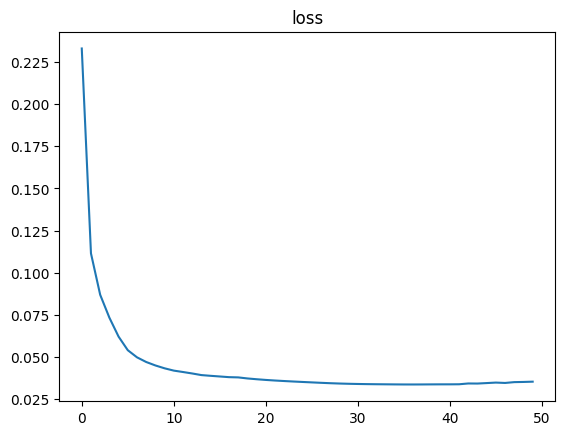

In [133]:
model.plot_history()

In [134]:
# Final predictions for training
z_pred_train = np.array([model.forward(inputs_train[i]) for i in range(Nx_train)]) # donne des valeurs entre 0 et 1
z_pred_int_train =  np.array([model.predict_label(inputs_train[i]) for i in range(Nx_train)]) # donne soit 1 soit 0

Accuracy : 99.01%


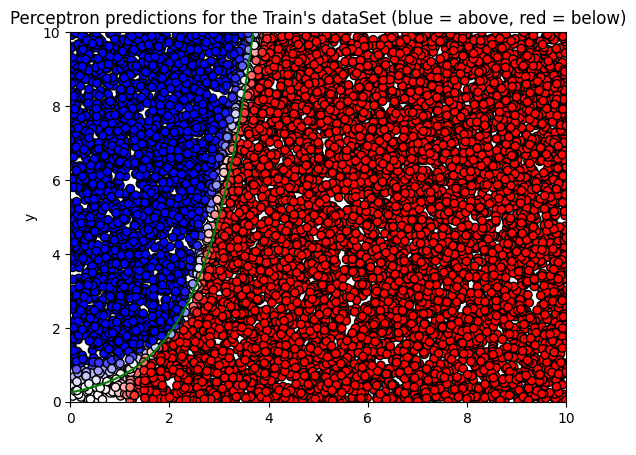

In [135]:
# accuracy of our MLP on the training data
print(f"Accuracy : {accuracy(z_true_train, z_pred_int_train) * 100:.2f}%")

# Display of final results for train
plot_classification(x_train, y_train, z_pred_train, g, title="Perceptron predictions for the Train's dataSet (blue = above, red = below)")

 ---

 ## Test

In [136]:
# initialization of a new set of random points for the test
x_test, y_test, inputs_test, z_true_test = generate_data(Nx_test, g)

In [137]:
# Final predictions for the test
z_pred_test = np.array([model.forward(inputs_test[i]) for i in range(Nx_test)]) # donne des valeurs entre 0 et 1
z_pred_int_test =  np.array([model.predict_label(inputs_test[i]) for i in range(Nx_test)]) # donne soit 1 soit 0

Accuracy : 99.30%


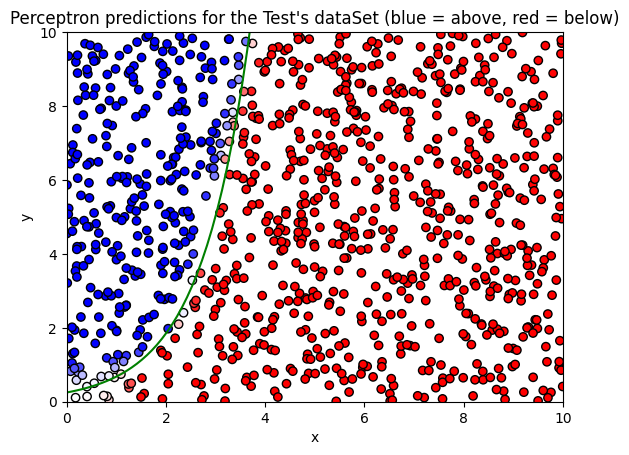

In [138]:
# accuracy of our MLP on the test data
print(f"Accuracy : {accuracy(z_true_test, z_pred_int_test) * 100:.2f}%")

# Display of final results for test
plot_classification(x_test, y_test, z_pred_test, g, title="Perceptron predictions for the Test's dataSet (blue = above, red = below)")

---

## MLP visualisation

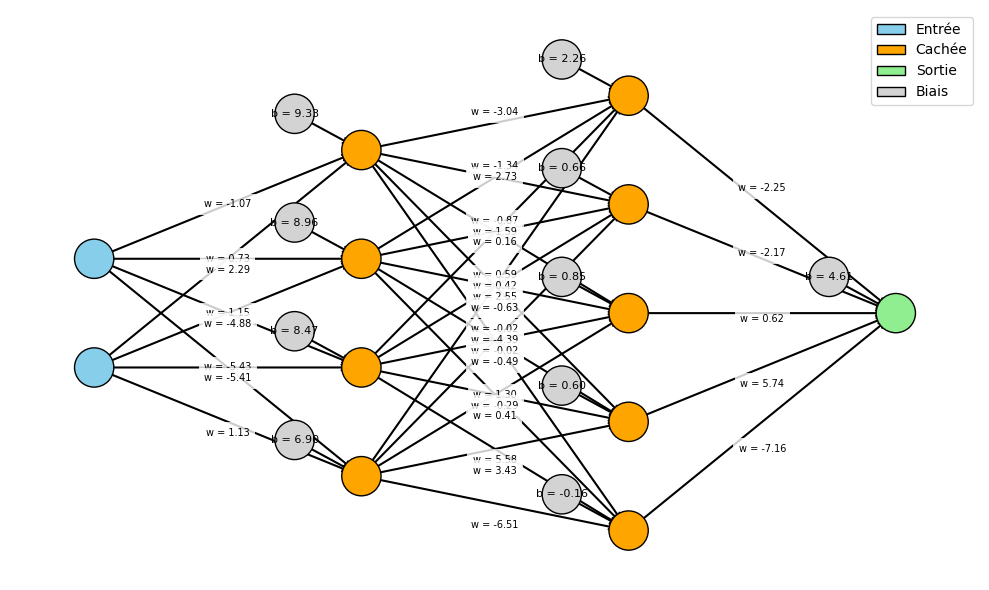

In [139]:
mlp_networkx_view(model)